In [19]:
import numpy as np
from scipy.spatial import ConvexHull, cKDTree
from scipy.interpolate import LinearNDInterpolator

# ============================================================
# Utilities: Heaviside, trilinear sampling
# ============================================================

def Hhat(phi, eps):
    """Smoothed Heaviside Ĥ(φ) with width eps."""
    phi = np.asarray(phi, dtype=np.float64)
    H = np.empty_like(phi)
    H[phi <= -eps] = 0.0
    H[phi >=  eps] = 1.0
    m = (np.abs(phi) < eps)
    H[m] = 0.5 * (1.0 + phi[m]/eps + (1.0/np.pi)*np.sin(np.pi*phi[m]/eps))
    return H

def trilinear_sample(grid, xs, ys, zs, points, fill_value=np.nan):
    """True trilinear sampling from a 3D grid to arbitrary points."""
    grid = np.asarray(grid)
    xs = np.asarray(xs); ys = np.asarray(ys); zs = np.asarray(zs)
    nx, ny, nz = grid.shape
    p = np.asarray(points, dtype=np.float64)

    ix = np.searchsorted(xs, p[:,0], side="right") - 1
    iy = np.searchsorted(ys, p[:,1], side="right") - 1
    iz = np.searchsorted(zs, p[:,2], side="right") - 1

    out = np.full(p.shape[0], fill_value, dtype=np.float64)
    valid = (ix >= 0) & (ix < nx-1) & (iy >= 0) & (iy < ny-1) & (iz >= 0) & (iz < nz-1)
    if not np.any(valid):
        return out

    ixv = ix[valid]; iyv = iy[valid]; izv = iz[valid]
    x0 = xs[ixv]; x1 = xs[ixv+1]
    y0 = ys[iyv]; y1 = ys[iyv+1]
    z0 = zs[izv]; z1 = zs[izv+1]

    tx = (p[valid,0] - x0) / (x1 - x0 + 1e-300)
    ty = (p[valid,1] - y0) / (y1 - y0 + 1e-300)
    tz = (p[valid,2] - z0) / (z1 - z0 + 1e-300)

    c000 = grid[ixv,   iyv,   izv]
    c100 = grid[ixv+1, iyv,   izv]
    c010 = grid[ixv,   iyv+1, izv]
    c110 = grid[ixv+1, iyv+1, izv]
    c001 = grid[ixv,   iyv,   izv+1]
    c101 = grid[ixv+1, iyv,   izv+1]
    c011 = grid[ixv,   iyv+1, izv+1]
    c111 = grid[ixv+1, iyv+1, izv+1]

    c00 = c000*(1-tx) + c100*tx
    c10 = c010*(1-tx) + c110*tx
    c01 = c001*(1-tx) + c101*tx
    c11 = c011*(1-tx) + c111*tx

    c0 = c00*(1-ty) + c10*ty
    c1 = c01*(1-ty) + c11*ty

    out[valid] = c0*(1-tz) + c1*tz
    return out

# ============================================================
# Grid derivatives + cofactors (3D)
# ============================================================

def grad3d_centered(F, dx, dy, dz):
    """Central differences in interior, one-sided at boundaries."""
    F = np.asarray(F, dtype=np.float64)
    dFx = np.empty_like(F)
    dFy = np.empty_like(F)
    dFz = np.empty_like(F)

    dFx[1:-1,:,:] = (F[2:,:,:] - F[:-2,:,:])/(2*dx)
    dFx[0,:,:]    = (F[1,:,:] - F[0,:,:])/dx
    dFx[-1,:,:]   = (F[-1,:,:] - F[-2,:,:])/dx

    dFy[:,1:-1,:] = (F[:,2:,:] - F[:,:-2,:])/(2*dy)
    dFy[:,0,:]    = (F[:,1,:] - F[:,0,:])/dy
    dFy[:,-1,:]   = (F[:,-1,:] - F[:,-2,:])/dy

    dFz[:,:,1:-1] = (F[:,:,2:] - F[:,:,:-2])/(2*dz)
    dFz[:,:,0]    = (F[:,:,1] - F[:,:,0])/dz
    dFz[:,:,-1]   = (F[:,:,-1] - F[:,:,-2])/dz
    return dFx, dFy, dFz

def cofactor3x3(G):
    """Cofactor matrix of a 3x3 matrix field G[...,3,3]."""
    g00,g01,g02 = G[...,0,0],G[...,0,1],G[...,0,2]
    g10,g11,g12 = G[...,1,0],G[...,1,1],G[...,1,2]
    g20,g21,g22 = G[...,2,0],G[...,2,1],G[...,2,2]

    C = np.empty_like(G)
    C[...,0,0] =  (g11*g22 - g12*g21)
    C[...,0,1] = -(g10*g22 - g12*g20)
    C[...,0,2] =  (g10*g21 - g11*g20)

    C[...,1,0] = -(g01*g22 - g02*g21)
    C[...,1,1] =  (g00*g22 - g02*g20)
    C[...,1,2] = -(g00*g21 - g01*g20)

    C[...,2,0] =  (g01*g12 - g02*g11)
    C[...,2,1] = -(g00*g12 - g02*g10)
    C[...,2,2] =  (g00*g11 - g01*g10)
    return C

# ============================================================
# Random enclosed 3D point set (demo)
# ============================================================

def build_random_enclosed_point_set(seed=0, n_surface=300, n_interior=900,
                                    scale=0.85, shift=(0.15,-0.05,0.10)):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2*np.pi, n_surface)
    phi = np.arccos(rng.uniform(-1, 1, n_surface))
    surf = np.stack([np.sin(phi)*np.cos(theta),
                     np.sin(phi)*np.sin(theta),
                     np.cos(phi)], axis=1)

    v = rng.normal(size=(n_interior, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    r = rng.uniform(0, 1, n_interior) ** (1/3)
    inner = v * r[:, None]

    pts = np.vstack([surf, inner])
    pts = scale*pts + np.asarray(shift, dtype=np.float64)
    return pts

# ============================================================
# NEW: Linear -> IDW kNN repair, ONLY on NaN nodes
# ============================================================

def interp_linear_then_idw_knn(
    pts, values, grid_points,
    fill_value=np.nan,
    kdtree=None,
    k=8,
    power=2.0,
    eps=1e-12
):
    """
    Scattered -> grid:
      1) LinearNDInterpolator
      2) Repair ONLY NaNs by k-NN inverse-distance weighting (IDW)
    values: (N,) or (N,d)
    returns: (M,) or (M,d)
    """
    pts = np.asarray(pts, dtype=np.float64)
    gp  = np.asarray(grid_points, dtype=np.float64)
    v   = np.asarray(values)

    if kdtree is None:
        kdtree = cKDTree(pts)

    def _idw_fill_scalar(nanmask, out_scalar, v_scalar):
        if not np.any(nanmask):
            return out_scalar
        kk = min(k, len(pts))
        d, idx = kdtree.query(gp[nanmask], k=kk)

        # normalize shape for kk=1
        if np.ndim(d) == 1:
            d = d[:, None]
            idx = idx[:, None]

        w = 1.0 / np.power(d + eps, power)
        wsum = np.sum(w, axis=1, keepdims=True)
        wsum = np.maximum(wsum, eps)

        vals = v_scalar[idx]          # (Mnan, kk)
        out_scalar[nanmask] = np.sum(w * vals, axis=1) / wsum[:, 0]
        return out_scalar

    # scalar
    if v.ndim == 1:
        lin = LinearNDInterpolator(pts, v, fill_value=fill_value)
        out = np.asarray(lin(gp), dtype=np.float64)
        nanmask = ~np.isfinite(out)
        return _idw_fill_scalar(nanmask, out, v)

    # vector/tensor (N,d)
    d = v.shape[1]
    out = np.empty((gp.shape[0], d), dtype=np.float64)
    for j in range(d):
        lin = LinearNDInterpolator(pts, v[:, j], fill_value=fill_value)
        tmp = np.asarray(lin(gp), dtype=np.float64)
        nanmask = ~np.isfinite(tmp)
        tmp = _idw_fill_scalar(nanmask, tmp, v[:, j])
        out[:, j] = tmp
    return out

# ============================================================
# Steps 1~3: pullback φ, reinit + trilinear + projection guard,
#            stresses (σ^s, σ^f) + mixture update (ρ, σ)
# ============================================================

def pipeline_part1_part2_part3(
    pts, xi_pts, u_pts, p_pts,
    phi0_func,
    mu_s=2.0, mu_f=0.08,
    rho_s=2.5, rho_f=1.0,
    epsH_factor=1.5,
    grid_dx=None, grid_pad=0.18,
    method="fmm",      # tries skfmm; falls back to EDT if missing
    fill_value=1e3,
    guard_band=2.5,
    idw_k=8,
    idw_power=2.0
):
    pts   = np.asarray(pts, dtype=np.float64)
    xi_pts= np.asarray(xi_pts, dtype=np.float64)
    u_pts = np.asarray(u_pts, dtype=np.float64)
    p_pts = np.asarray(p_pts, dtype=np.float64).reshape(-1)
    assert pts.shape == xi_pts.shape == u_pts.shape and pts.shape[1] == 3

    # -----------------------
    # (1) Pullback φ(x,t)=φ0(ξ(x,t))
    # -----------------------
    phi_xt = np.asarray(phi0_func(xi_pts), dtype=np.float64).reshape(-1)

    # -----------------------
    # Embedding grid
    # -----------------------
    xmin = pts.min(axis=0); xmax = pts.max(axis=0)
    extent = xmax - xmin
    pad = grid_pad * np.maximum(extent, 1e-12)
    gmin = xmin - pad; gmax = xmax + pad

    if grid_dx is None:
        tree = cKDTree(pts)
        d, _ = tree.query(pts, k=2)
        h = np.median(d[:, 1])
        h = max(h, 1e-3*np.max(extent))
        dx = (h, h, h)
    else:
        dx = (float(grid_dx),)*3 if np.isscalar(grid_dx) else tuple(map(float, grid_dx))

    xs = np.arange(gmin[0], gmax[0] + dx[0], dx[0])
    ys = np.arange(gmin[1], gmax[1] + dx[1], dx[1])
    zs = np.arange(gmin[2], gmax[2] + dx[2], dx[2])

    Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
    grid_points = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

    # One KDTree reused for all IDW repairs
    kdt = cKDTree(pts)

    # φ on grid: linear is fine (it already has fill_value for out-of-hull)
    phi_grid = LinearNDInterpolator(pts, phi_xt, fill_value=fill_value)(grid_points).reshape(Xg.shape)

    # ξ and u on grid: linear -> IDW repair (NaNs-only)
    xi_g = interp_linear_then_idw_knn(
        pts, xi_pts, grid_points, fill_value=np.nan, kdtree=kdt, k=idw_k, power=idw_power
    )
    u_g = interp_linear_then_idw_knn(
        pts, u_pts, grid_points, fill_value=np.nan, kdtree=kdt, k=idw_k, power=idw_power
    )
    # pressure too (prevents -pI NaNs)
    p_g = interp_linear_then_idw_knn(
        pts, p_pts, grid_points, fill_value=np.nan, kdtree=kdt, k=idw_k, power=idw_power
    )

    xi0g = xi_g[:,0].reshape(Xg.shape); xi1g = xi_g[:,1].reshape(Xg.shape); xi2g = xi_g[:,2].reshape(Xg.shape)
    u0g  = u_g[:,0].reshape(Xg.shape);  u1g  = u_g[:,1].reshape(Xg.shape);  u2g  = u_g[:,2].reshape(Xg.shape)
    pg   = p_g.reshape(Xg.shape)

    # -----------------------
    # (2) Reinit φ -> φ̂ (FMM if available else EDT)
    # -----------------------
    used = method
    if method == "fmm":
        try:
            import skfmm
            phi_grid_reinit = skfmm.distance(phi_grid, dx=dx)
        except Exception:
            used = "edt"
            from scipy.ndimage import distance_transform_edt
            inside = phi_grid < 0
            phi_grid_reinit = distance_transform_edt(~inside, sampling=dx) - distance_transform_edt(inside, sampling=dx)
    else:
        from scipy.ndimage import distance_transform_edt
        inside = phi_grid < 0
        phi_grid_reinit = distance_transform_edt(~inside, sampling=dx) - distance_transform_edt(inside, sampling=dx)

    # Sample φ̂ back to points (true trilinear)
    phi_hat_pts = trilinear_sample(phi_grid_reinit, xs, ys, zs, pts, fill_value=np.nan)

    # Projection guard in band: sign(φ)*max(|φ̂|,|φ|)
    band = guard_band * float(np.mean(dx))
    near = np.isfinite(phi_hat_pts) & (np.abs(phi_xt) <= band)
    phi_hat_pts_guarded = phi_hat_pts.copy()
    s = np.sign(phi_xt[near])
    mag = np.maximum(np.abs(phi_hat_pts_guarded[near]), np.abs(phi_xt[near]))
    phi_hat_pts_guarded[near] = s * mag

    # -----------------------
    # (3) Compute σ^s, σ^f and update mixture ρ, σ via Ĥ(φ̂)
    # -----------------------
    epsH = epsH_factor * float(np.mean(dx))
    Hgrid = Hhat(phi_grid_reinit, epsH)

    # ∇ξ
    dxi0_dx, dxi0_dy, dxi0_dz = grad3d_centered(xi0g, dx[0], dx[1], dx[2])
    dxi1_dx, dxi1_dy, dxi1_dz = grad3d_centered(xi1g, dx[0], dx[1], dx[2])
    dxi2_dx, dxi2_dy, dxi2_dz = grad3d_centered(xi2g, dx[0], dx[1], dx[2])

    G = np.zeros(xi0g.shape + (3,3), dtype=np.float64)
    G[...,0,0], G[...,0,1], G[...,0,2] = dxi0_dx, dxi0_dy, dxi0_dz
    G[...,1,0], G[...,1,1], G[...,1,2] = dxi1_dx, dxi1_dy, dxi1_dz
    G[...,2,0], G[...,2,1], G[...,2,2] = dxi2_dx, dxi2_dy, dxi2_dz

    cofG = cofactor3x3(G)
    I = np.eye(3)[None,None,None,:,:]

    # Solid stress: 2 μ_s cof(∇ξ)cof(∇ξ)^T - pI   (2D Eq.11 structure extended to 3D)
    sigma_s = 2.0*mu_s * (cofG @ np.swapaxes(cofG, -1, -2)) - pg[...,None,None]*I

    # Fluid stress: μ_f (∇u + ∇u^T) - pI  (Eq.12 extension to 3D)
    du0_dx, du0_dy, du0_dz = grad3d_centered(u0g, dx[0], dx[1], dx[2])
    du1_dx, du1_dy, du1_dz = grad3d_centered(u1g, dx[0], dx[1], dx[2])
    du2_dx, du2_dy, du2_dz = grad3d_centered(u2g, dx[0], dx[1], dx[2])

    Gu = np.zeros(u0g.shape + (3,3), dtype=np.float64)
    Gu[...,0,0], Gu[...,0,1], Gu[...,0,2] = du0_dx, du0_dy, du0_dz
    Gu[...,1,0], Gu[...,1,1], Gu[...,1,2] = du1_dx, du1_dy, du1_dz
    Gu[...,2,0], Gu[...,2,1], Gu[...,2,2] = du2_dx, du2_dy, du2_dz

    sigma_f = mu_f * (Gu + np.swapaxes(Gu, -1, -2)) - pg[...,None,None]*I

    # Mixture update
    rho_grid = Hgrid*rho_f + (1.0-Hgrid)*rho_s
    sigma_grid = Hgrid[...,None,None]*sigma_f + (1.0-Hgrid[...,None,None])*sigma_s

    # Sample mixture fields back to points
    rho_pts = trilinear_sample(rho_grid, xs, ys, zs, pts, fill_value=np.nan)

    sigma_pts = np.zeros((pts.shape[0], 3, 3), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            sigma_pts[:, i, j] = trilinear_sample(sigma_grid[...,i,j], xs, ys, zs, pts, fill_value=np.nan)

    # NaN stats for sanity
    nan_stats = {
        "xi_grid_nan_frac": float(np.mean(~np.isfinite(xi_g))),
        "u_grid_nan_frac":  float(np.mean(~np.isfinite(u_g))),
        "p_grid_nan_frac":  float(np.mean(~np.isfinite(p_g))),
        "sigma_grid_nan_frac": float(np.mean(~np.isfinite(sigma_grid))),
        "rho_pts_nan_frac": float(np.mean(~np.isfinite(rho_pts))),
        "sigma_pts_nan_frac": float(np.mean(~np.isfinite(sigma_pts))),
    }

    return {
        "phi_xt": phi_xt,
        "phi_hat_pts": phi_hat_pts_guarded,
        "phi_hat_grid": phi_grid_reinit,
        "H_grid": Hgrid,
        "rho_grid": rho_grid,
        "sigma_grid": sigma_grid,
        "rho_pts": rho_pts,
        "sigma_pts": sigma_pts,
        "grid_axes": (xs, ys, zs),
        "dx": dx,
        "epsH": epsH,
        "method_used": used,
        "nan_stats": nan_stats
    }

# ============================================================
# Demo run (kept aligned with your original structure)
# ============================================================

if __name__ == "__main__":
    pts = build_random_enclosed_point_set(seed=42, n_surface=320, n_interior=900)
    hull = ConvexHull(pts)

    # Demo ξ(x,t): masked back-map shift
    center = pts.mean(axis=0)
    Rmask = 0.55
    dist = np.linalg.norm(pts - center[None, :], axis=1)
    Hn = (dist <= Rmask).astype(np.float64)

    u_adv = np.array([0.45, 0.10, -0.20])
    t = 0.06
    xi = pts - (Hn[:, None] * t) * u_adv[None, :]

    # Demo u(x): swirl + axial
    omega = 1.2
    rel = pts - center[None,:]
    u_pts = np.column_stack([-omega*rel[:,1], omega*rel[:,0], 0.25*np.sin(2*rel[:,2])])

    # Demo pressure
    p_pts = 0.2*(rel[:,0]**2 + rel[:,1]**2 - 0.5*rel[:,2]**2)

    # φ0(ξ): sphere SDF in reference
    c0 = np.array([0.15, -0.05, 0.10])
    R0 = 0.52
    def phi0_sphere(X):
        return np.linalg.norm(X - c0[None, :], axis=1) - R0

    out = pipeline_part1_part2_part3(
        pts=pts, xi_pts=xi, u_pts=u_pts, p_pts=p_pts,
        phi0_func=phi0_sphere,
        mu_s=2.0, mu_f=0.08,
        rho_s=2.5, rho_f=1.0,
        epsH_factor=1.5,
        grid_dx=None, grid_pad=0.18,
        method="fmm",
        fill_value=1e3,
        guard_band=2.5,
        idw_k=8,
        idw_power=2.0
    )

    phi_xt = out["phi_xt"]
    phi_hat = out["phi_hat_pts"]
    rho_pts = out["rho_pts"]
    sigma_pts = out["sigma_pts"]

    band = 2.5*float(np.mean(out["dx"]))
    near = np.abs(phi_xt) <= band

    print("=== Convex Hull ===")
    print("points:", pts.shape[0])
    print("hull vertices:", len(hull.vertices))
    print("hull triangles:", hull.simplices.shape[0])
    print("hull volume:", hull.volume)
    print("hull area:", hull.area)

    print("\n=== Step 1+2: phi pullback + reinit ===")
    print("method used:", out["method_used"])
    print("grid dx:", out["dx"], "epsH:", out["epsH"])
    print("phi_xt range:", (float(phi_xt.min()), float(phi_xt.max())))
    print("phi_hat range:", (float(np.nanmin(phi_hat)), float(np.nanmax(phi_hat))))
    print("sign mismatch near:",
          float(np.mean(np.sign(phi_hat[near]) != np.sign(phi_xt[near]))))
    print("shrink rate near:",
          float(np.mean((np.abs(phi_hat[near])+1e-15) < (np.abs(phi_xt[near])-1e-15))))

    print("\n=== IDW NaN-repair stats ===")
    for k, v in out["nan_stats"].items():
        print(k, "=", v)

    print("\n=== Step 3: mixture rho and stress ===")
    print("rho_pts range:", (float(np.nanmin(rho_pts)), float(np.nanmax(rho_pts))))
    print("sigma symmetry max|σ-σᵀ|:",
          float(np.nanmax(np.abs(sigma_pts - np.swapaxes(sigma_pts,1,2)))))

    rng = np.random.default_rng(3)
    idx = rng.choice(len(pts), size=5, replace=False)
    print("\nSample points:")
    for i in idx:
        print("x=", pts[i],
              "phi_xt=", float(phi_xt[i]),
              "phi_hat=", float(phi_hat[i]),
              "rho=", float(rho_pts[i]),
              "sigma_xx=", float(sigma_pts[i,0,0]),
              "sigma_xy=", float(sigma_pts[i,0,1]))

=== Convex Hull ===
points: 1220
hull vertices: 345
hull triangles: 686
hull volume: 2.4850822938698114
hull area: 8.920442126350903

=== Step 1+2: phi pullback + reinit ===
method used: fmm
grid dx: (np.float64(0.07591970042989786), np.float64(0.07591970042989786), np.float64(0.07591970042989786)) epsH: 0.11387955064484678
phi_xt range: (-0.4498139658766448, 0.33000000000000007)
phi_hat range: (-0.41847248646325663, 0.3772085161635751)
sign mismatch near: 0.0
shrink rate near: 0.0

=== IDW NaN-repair stats ===
xi_grid_nan_frac = 0.0
u_grid_nan_frac = 0.0
p_grid_nan_frac = 0.0
sigma_grid_nan_frac = 0.0
rho_pts_nan_frac = 0.0
sigma_pts_nan_frac = 0.0

=== Step 3: mixture rho and stress ===
rho_pts range: (1.0, 2.5000000000000004)
sigma symmetry max|σ-σᵀ|: 0.0

Sample points:
x= [ 0.71801738 -0.32799208 -0.46795832] phi_xt= 0.32999999999999996 phi_hat= 0.3291112607340897 rho= 1.0 sigma_xx= -0.07537265720407835 sigma_xy= -0.004850079246904409
x= [ 0.02862535 -0.62459143 -0.11011068] phi_x

In [20]:
import numpy as np
from scipy.spatial import ConvexHull

def grid_from_convex_hull(pts, grid_dx=None, grid_pad=0.18):
    """
    Returns:
      xs, ys, zs: grid axes
      Xg, Yg, Zg: meshgrid (ij indexing)
      inside: (nx,ny,nz) bool mask for points inside the convex hull
      hull: ConvexHull object
    """
    pts = np.asarray(pts, dtype=np.float64)
    hull = ConvexHull(pts)

    xmin = pts.min(axis=0)
    xmax = pts.max(axis=0)
    extent = xmax - xmin
    pad = grid_pad * np.maximum(extent, 1e-12)
    gmin = xmin - pad
    gmax = xmax + pad

    if grid_dx is None:
        # crude spacing: bbox / 32 (similar scale to your earlier grid (32^3))
        h = np.max(extent) / 32.0
        h = max(h, 1e-3*np.max(extent))
        dx = (h, h, h)
    else:
        dx = (float(grid_dx),)*3 if np.isscalar(grid_dx) else tuple(map(float, grid_dx))

    xs = np.arange(gmin[0], gmax[0] + dx[0], dx[0])
    ys = np.arange(gmin[1], gmax[1] + dx[1], dx[1])
    zs = np.arange(gmin[2], gmax[2] + dx[2], dx[2])

    Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
    grid_points = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])  # (M,3)

    # Hull half-space equations: (a,b,c,d) where a*x + b*y + c*z + d <= 0 inside
    eq = hull.equations  # (nf,4)
    A = eq[:, :3]        # (nf,3)
    d = eq[:, 3]         # (nf,)

    # Evaluate all inequalities for all points: A @ x + d <= 0
    # result shape: (nf, M)
    vals = (A @ grid_points.T) + d[:, None]
    inside_flat = np.all(vals <= 1e-12, axis=0)  # small tolerance
    inside = inside_flat.reshape(Xg.shape)

    return xs, ys, zs, Xg, Yg, Zg, inside, hull, dx

def init_u_p_on_hull_grid(Xg, Yg, Zg, inside, center=None,
                         u_mode="swirl", p_mode="bump"):
    """
    Returns:
      u_grid: (nx,ny,nz,3)
      p_grid: (nx,ny,nz)
    """
    nx, ny, nz = Xg.shape
    u_grid = np.zeros((nx, ny, nz, 3), dtype=np.float64)
    p_grid = np.zeros((nx, ny, nz), dtype=np.float64)

    if center is None:
        center = np.array([Xg.mean(), Yg.mean(), Zg.mean()], dtype=np.float64)

    rx = Xg - center[0]
    ry = Yg - center[1]
    rz = Zg - center[2]

    if u_mode == "swirl":
        omega = 1.2
        u_grid[..., 0] = -omega * ry
        u_grid[..., 1] =  omega * rx
        u_grid[..., 2] =  0.25 * np.sin(2.0 * rz)
    elif u_mode == "zero":
        pass
    else:
        raise ValueError("u_mode must be 'swirl' or 'zero'")

    if p_mode == "bump":
        p_grid = 0.2 * (rx*rx + ry*ry - 0.5*rz*rz)
    elif p_mode == "zero":
        p_grid[:] = 0.0
    else:
        raise ValueError("p_mode must be 'bump' or 'zero'")

    # enforce convex-hull restriction:
    u_grid[~inside, :] = 0.0
    p_grid[~inside] = 0.0

    return u_grid, p_grid

# given your point cloud pts:
xs, ys, zs, Xg, Yg, Zg, inside, hull, dx = grid_from_convex_hull(pts, grid_dx=None, grid_pad=0.18)

# define fields *by the hull*
u_grid, p_grid = init_u_p_on_hull_grid(Xg, Yg, Zg, inside, center=pts.mean(axis=0),
                                       u_mode="swirl", p_mode="bump")

# "time n" fields (copies)
u_grid_n = u_grid.copy()
p_grid_n = p_grid.copy()

In [21]:
import numpy as np

# ----------------------------
# FD helpers (3D)
# ----------------------------
def grad3_centered(F, dx, dy, dz):
    Fx = np.empty_like(F); Fy = np.empty_like(F); Fz = np.empty_like(F)
    Fx[1:-1,:,:] = (F[2:,:,:] - F[:-2,:,:])/(2*dx);  Fx[0,:,:] = (F[1,:,:]-F[0,:,:])/dx;  Fx[-1,:,:]=(F[-1,:,:]-F[-2,:,:])/dx
    Fy[:,1:-1,:] = (F[:,2:,:] - F[:,:-2,:])/(2*dy);  Fy[:,0,:] = (F[:,1,:]-F[:,0,:])/dy;  Fy[:,-1,:]=(F[:,-1,:]-F[:,-2,:])/dy
    Fz[:,:,1:-1] = (F[:,:,2:] - F[:,:,:-2])/(2*dz);  Fz[:,:,0] = (F[:,:,1]-F[:,:,0])/dz;  Fz[:,:,-1]=(F[:,:,-1]-F[:,:,-2])/dz
    return Fx, Fy, Fz

def div3_centered(Fx, Fy, Fz, dx, dy, dz):
    """Divergence of a vector field given by components Fx,Fy,Fz on cell centers."""
    dFx_dx = np.empty_like(Fx); dFy_dy = np.empty_like(Fy); dFz_dz = np.empty_like(Fz)
    dFx_dx[1:-1,:,:] = (Fx[2:,:,:] - Fx[:-2,:,:])/(2*dx); dFx_dx[0,:,:]=(Fx[1,:,:]-Fx[0,:,:])/dx; dFx_dx[-1,:,:]=(Fx[-1,:,:]-Fx[-2,:,:])/dx
    dFy_dy[:,1:-1,:] = (Fy[:,2:,:] - Fy[:,:-2,:])/(2*dy); dFy_dy[:,0,:]=(Fy[:,1,:]-Fy[:,0,:])/dy; dFy_dy[:,-1,:]=(Fy[:,-1,:]-Fy[:,-2,:])/dy
    dFz_dz[:,:,1:-1] = (Fz[:,:,2:] - Fz[:,:,:-2])/(2*dz); dFz_dz[:,:,0]=(Fz[:,:,1]-Fz[:,:,0])/dz; dFz_dz[:,:,-1]=(Fz[:,:,-1]-Fz[:,:,-2])/dz
    return dFx_dx + dFy_dy + dFz_dz

def div_tensor_sigma(sigma, dx, dy, dz):
    """
    sigma: (...,3,3) on cell centers.
    returns div(sigma): (...,3) with (∂σ_{i0}/∂x + ∂σ_{i1}/∂y + ∂σ_{i2}/∂z).
    """
    out = np.zeros(sigma.shape[:-1], dtype=np.float64)  # (...,3)
    # For each i, divergence uses derivatives of sigma[i,j] along j-axis coordinate
    for i in range(3):
        s_ix = sigma[..., i, 0]
        s_iy = sigma[..., i, 1]
        s_iz = sigma[..., i, 2]
        dsx_dx, _, _ = grad3_centered(s_ix, dx, dy, dz)
        _, dsy_dy, _ = grad3_centered(s_iy, dx, dy, dz)
        _, _, dsz_dz = grad3_centered(s_iz, dx, dy, dz)
        out[..., i] = dsx_dx + dsy_dy + dsz_dz
    return out  # (...,3)

# ----------------------------
# Simple face interpolation + face divergence (Rhie–Chow-like)
# ----------------------------
def interp_to_xfaces(F):
    # x-faces between i and i+1: shape (nx-1,ny,nz)
    return 0.5*(F[:-1,:,:] + F[1:,:,:])

def interp_to_yfaces(F):
    return 0.5*(F[:,:-1,:] + F[:,1:,:])

def interp_to_zfaces(F):
    return 0.5*(F[:,:,:-1] + F[:,:,1:])

def div_from_face_flux(Fx_f, Fy_f, Fz_f, dx, dy, dz):
    """
    Divergence of face-centered fluxes into cell centers.
      Fx_f: (nx-1,ny,nz) on x-faces
      Fy_f: (nx,ny-1,nz) on y-faces
      Fz_f: (nx,ny,nz-1) on z-faces
    returns: (nx,ny,nz)
    """
    nx = Fy_f.shape[0]
    ny = Fx_f.shape[1]
    nz = Fx_f.shape[2]
    div = np.zeros((nx,ny,nz), dtype=np.float64)
    # x
    div[1:-1,:,:] += (Fx_f[1:,:,:] - Fx_f[:-1,:,:]) / dx
    div[0,:,:]    += (Fx_f[0,:,:]) / dx
    div[-1,:,:]   += (-Fx_f[-1,:,:]) / dx
    # y
    div[:,1:-1,:] += (Fy_f[:,1:,:] - Fy_f[:,:-1,:]) / dy
    div[:,0,:]    += (Fy_f[:,0,:]) / dy
    div[:,-1,:]   += (-Fy_f[:,-1,:]) / dy
    # z
    div[:,:,1:-1] += (Fz_f[:,:,1:] - Fz_f[:,:,:-1]) / dz
    div[:,:,0]    += (Fz_f[:,:,0]) / dz
    div[:,:,-1]   += (-Fz_f[:,:,-1]) / dz
    return div

# ----------------------------
# Variable-coefficient Poisson (Jacobi)
#   ∇·( (1/rho) ∇δp ) = RHS
# ----------------------------
def solve_poisson_variable_coeff_jacobi(rhs, inv_rho, dx, dy, dz, iters=400, omega=0.8):
    """
    Solve:
        div( inv_rho * grad(dp) ) = rhs
    on a collocated grid using Jacobi iteration.

    rhs:     (nx, ny, nz)
    inv_rho: (nx, ny, nz)
    """
    rhs = np.asarray(rhs, dtype=np.float64)
    inv_rho = np.asarray(inv_rho, dtype=np.float64)

    nx, ny, nz = rhs.shape
    dp = np.zeros_like(rhs, dtype=np.float64)

    dx2 = dx * dx
    dy2 = dy * dy
    dz2 = dz * dz

    # face coefficients
    ax = 0.5 * (inv_rho[:-1, :, :] + inv_rho[1:, :, :])   # (nx-1, ny,   nz)
    ay = 0.5 * (inv_rho[:, :-1, :] + inv_rho[:, 1:, :])   # (nx,   ny-1, nz)
    az = 0.5 * (inv_rho[:, :, :-1] + inv_rho[:, :, 1:])   # (nx,   ny,   nz-1)

    for _ in range(iters):
        dp_new = dp.copy()

        # interior cells only
        for i in range(1, nx - 1):
            for j in range(1, ny - 1):
                for k in range(1, nz - 1):
                    axm = ax[i - 1, j, k]   # face between i-1 and i
                    axp = ax[i,     j, k]   # face between i and i+1
                    aym = ay[i, j - 1, k]   # face between j-1 and j
                    ayp = ay[i, j,     k]   # face between j and j+1
                    azm = az[i, j, k - 1]   # face between k-1 and k
                    azp = az[i, j, k]       # face between k and k+1

                    denom = (
                        (axm + axp) / dx2 +
                        (aym + ayp) / dy2 +
                        (azm + azp) / dz2
                    )

                    numer = (
                        (axm * dp[i - 1, j, k] + axp * dp[i + 1, j, k]) / dx2 +
                        (aym * dp[i, j - 1, k] + ayp * dp[i, j + 1, k]) / dy2 +
                        (azm * dp[i, j, k - 1] + azp * dp[i, j, k + 1]) / dz2
                    )

                    dp_new[i, j, k] = (numer - rhs[i, j, k]) / max(denom, 1e-30)

        # simple Neumann-style copy at boundaries
        dp_new[0, :, :]  = dp_new[1, :, :]
        dp_new[-1, :, :] = dp_new[-2, :, :]
        dp_new[:, 0, :]  = dp_new[:, 1, :]
        dp_new[:, -1, :] = dp_new[:, -2, :]
        dp_new[:, :, 0]  = dp_new[:, :, 1]
        dp_new[:, :, -1] = dp_new[:, :, -2]

        dp = (1.0 - omega) * dp + omega * dp_new

    # remove null-space constant
    dp -= np.mean(dp)
    return dp

# ============================================================
# Steps 4,5,6
# ============================================================

def steps_4_5_6(
    u_grid,           # (nx,ny,nz,3) velocity at time n
    p_grid,           # (nx,ny,nz) pressure at time n
    rho_grid_np1,     # (nx,ny,nz) rho at time n+1 (from mixture)
    sigma_grid_np1,   # (nx,ny,nz,3,3) sigma at time n+1 (from mixture)
    dt,
    dx_tuple,         # (dx,dy,dz)
    body_force=None,  # optional (nx,ny,nz,3) or None
    poisson_iters=400
):
    """
    Step 4: compute intermediate u* then u** (Eq 14,15)
    Step 5: compute face velocity u_f** (Rhie–Chow-like, Eq 16)
    Step 6: solve pressure correction Poisson for δp (Eq 17) and correct u,p
    """
    dx, dy, dz = dx_tuple
    rho = rho_grid_np1
    inv_rho = 1.0/np.maximum(rho, 1e-12)

    u = u_grid
    p = p_grid

    if body_force is None:
        body_force = np.zeros_like(u)

    # --------------------
    # Step 4a (Eq 14): advection (conservative form) -> u*
    #   (rho^{n+1} u* - rho^n u^n)/dt = - div( rho u⊗u )^n
    # Here we approximate rho^n ~ rho^{n+1} (precomputed assumption).
    # --------------------
    # Build flux tensor components: (rho u_i u_j)
    rho_u0 = rho * u[...,0]
    rho_u1 = rho * u[...,1]
    rho_u2 = rho * u[...,2]

    # For each component i, compute div of vector (rho u_i u) = [rho u_i u0, rho u_i u1, rho u_i u2]
    adv = np.zeros_like(u)
    for i, ui in enumerate([u[...,0], u[...,1], u[...,2]]):
        Fx = rho * ui * u[...,0]
        Fy = rho * ui * u[...,1]
        Fz = rho * ui * u[...,2]
        adv[..., i] = div3_centered(Fx, Fy, Fz, dx, dy, dz)

    u_star = (rho[..., None] * u - dt * adv) * inv_rho[..., None]  # u* = u - dt/rho div( rho u⊗u )

    # --------------------
    # Step 4b (Eq 15): diffusion/solid term via div(sigma)
    #   rho (u** - u*)/dt = div sigma( ... )
    # If sigma contains -pI, you usually should NOT include that here (pressure is handled by step 6).
    # We strip it: sigma_eff = sigma + pI
    # --------------------
    I = np.eye(3, dtype=np.float64)[None,None,None,:,:]
    sigma_eff = sigma_grid_np1 + p[...,None,None]*I  # remove -pI if present
    divsig = div_tensor_sigma(sigma_eff, dx, dy, dz)  # (nx,ny,nz,3)

    u_dblstar = u_star + dt * inv_rho[...,None] * (divsig + body_force)

    # --------------------
    # Step 5 (Eq 16): Rhie–Chow-like face velocity
    # u_f = <u**>_{P->f} - dt/rho_f * ( (grad p)_f - F_f )
    # We'll take F_f = body_force at faces (optional), else 0.
    # --------------------
    # Interpolate u** to faces
    ux, uy, uz = u_dblstar[...,0], u_dblstar[...,1], u_dblstar[...,2]
    ux_xf = interp_to_xfaces(ux); uy_xf = interp_to_xfaces(uy); uz_xf = interp_to_xfaces(uz)
    ux_yf = interp_to_yfaces(ux); uy_yf = interp_to_yfaces(uy); uz_yf = interp_to_yfaces(uz)
    ux_zf = interp_to_zfaces(ux); uy_zf = interp_to_zfaces(uy); uz_zf = interp_to_zfaces(uz)

    # Face densities (avg)
    rho_xf = interp_to_xfaces(rho)
    rho_yf = interp_to_yfaces(rho)
    rho_zf = interp_to_zfaces(rho)
    inv_rho_xf = 1.0/np.maximum(rho_xf, 1e-12)
    inv_rho_yf = 1.0/np.maximum(rho_yf, 1e-12)
    inv_rho_zf = 1.0/np.maximum(rho_zf, 1e-12)

    # Pressure gradients at faces (use centered diff of p at faces)
    # x-faces: dp/dx between i and i+1
    dpdx_xf = (p[1:,:,:] - p[:-1,:,:]) / dx
    dpdy_yf = (p[:,1:,:] - p[:,:-1,:]) / dy
    dpdz_zf = (p[:,:,1:] - p[:,:,:-1]) / dz

    # For Rhie–Chow term, we need (∇p)_f as a vector on each face.
    # We'll use only the normal gradient component on that face (simplified but common).
    # Subtract dt/rho_f * grad(p)_normal in the corresponding normal component of u_f.

    # x-faces velocity vector
    uxf = np.stack([ux_xf, uy_xf, uz_xf], axis=-1)
    uxf[...,0] -= dt * inv_rho_xf * dpdx_xf  # normal correction

    # y-faces
    uyf = np.stack([ux_yf, uy_yf, uz_yf], axis=-1)
    uyf[...,1] -= dt * inv_rho_yf * dpdy_yf

    # z-faces
    uzf = np.stack([ux_zf, uy_zf, uz_zf], axis=-1)
    uzf[...,2] -= dt * inv_rho_zf * dpdz_zf

    # --------------------
    # Step 6 (Eq 17): pressure correction Poisson
    # div( (1/rho_f) grad δp ) = - div( u_f / dt )
    # We'll build RHS using face fluxes of u_f (normal components) / dt.
    # --------------------
    # Face fluxes = u_normal at faces
    Fx = uxf[...,0]  # (nx-1,ny,nz)
    Fy = uyf[...,1]  # (nx,ny-1,nz)
    Fz = uzf[...,2]  # (nx,ny,nz-1)

    rhs = -div_from_face_flux(Fx/dt, Fy/dt, Fz/dt, dx, dy, dz)  # (nx,ny,nz)

    # Solve for δp
    dp = solve_poisson_variable_coeff_jacobi(rhs, inv_rho, dx, dy, dz, iters=poisson_iters, omega=0.8)

    # Correct cell-centered velocity: u^{n+1} = u** - dt/rho * grad δp
    dp_dx, dp_dy, dp_dz = grad3_centered(dp, dx, dy, dz)
    u_np1 = u_dblstar - dt * inv_rho[...,None] * np.stack([dp_dx, dp_dy, dp_dz], axis=-1)

    # Update pressure
    p_np1 = p + dp

    return u_star, u_dblstar, u_np1, p_np1, dp

In [22]:
import numpy as np
import pyvista as pv


def build_pyvista_grid_from_fields(xs, ys, zs, u_grid, p_grid, inside_mask=None):
    """
    Build a PyVista RectilinearGrid from Cartesian axes and attach fields.

    Parameters
    ----------
    xs, ys, zs : 1D arrays
        Grid axes.
    u_grid : ndarray, shape (nx, ny, nz, 3)
        Velocity field.
    p_grid : ndarray, shape (nx, ny, nz)
        Pressure field.
    inside_mask : ndarray, shape (nx, ny, nz), optional
        Boolean mask for inside-hull cells.

    Returns
    -------
    grid : pv.RectilinearGrid
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)

    u_grid = np.asarray(u_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)

    nx, ny, nz = p_grid.shape
    assert u_grid.shape == (nx, ny, nz, 3)

    grid = pv.RectilinearGrid(xs, ys, zs)

    # PyVista expects point data flattened in Fortran order for meshgrid(indexing="ij") style grids
    grid["pressure"] = p_grid.ravel(order="F")
    grid["velocity"] = u_grid.reshape(-1, 3, order="F")

    speed = np.linalg.norm(u_grid, axis=-1)
    grid["speed"] = speed.ravel(order="F")

    if inside_mask is not None:
        inside_mask = np.asarray(inside_mask, dtype=bool)
        assert inside_mask.shape == (nx, ny, nz)
        grid["inside_mask"] = inside_mask.astype(np.uint8).ravel(order="F")

    return grid


def build_hull_surface_polydata(pts, hull):
    """
    Convert scipy.spatial.ConvexHull triangles into a PyVista PolyData surface.
    """
    faces = []
    for tri in hull.simplices:
        faces.extend([3, int(tri[0]), int(tri[1]), int(tri[2])])
    faces = np.array(faces, dtype=np.int64)
    return pv.PolyData(np.asarray(pts, dtype=float), faces)


def masked_seed_points(xs, ys, zs, inside_mask, stride=3, jitter=False, seed=0):
    """
    Create streamline seed points from the inside-mask on a subsampled grid.
    """
    Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
    mask_sub = inside_mask[::stride, ::stride, ::stride]
    Xs = Xg[::stride, ::stride, ::stride][mask_sub]
    Ys = Yg[::stride, ::stride, ::stride][mask_sub]
    Zs = Zg[::stride, ::stride, ::stride][mask_sub]

    pts = np.column_stack([Xs, Ys, Zs])

    if jitter and len(pts) > 0:
        rng = np.random.default_rng(seed)
        dx = float(np.mean(np.diff(xs))) if len(xs) > 1 else 0.0
        dy = float(np.mean(np.diff(ys))) if len(ys) > 1 else 0.0
        dz = float(np.mean(np.diff(zs))) if len(zs) > 1 else 0.0
        noise = rng.uniform(-0.2, 0.2, size=pts.shape) * np.array([dx, dy, dz])
        pts = pts + noise

    return pv.PolyData(pts)


def plot_pressure_slices_streamlines(
    xs,
    ys,
    zs,
    u_grid,
    p_grid,
    inside_mask=None,
    pts=None,
    hull=None,
    show_volume=True,
    show_slices=True,
    show_streamlines=True,
    show_glyphs=False,
    show_hull=True,
    streamline_stride=3,
    streamline_max_length=None,
    glyph_stride=4,
    notebook=False,
):
    """
    Interactive PyVista visualization:
      - pressure volume
      - interactive orthogonal pressure slices
      - velocity glyphs
      - streamlines
      - convex hull overlay
    """
    grid = build_pyvista_grid_from_fields(xs, ys, zs, u_grid, p_grid, inside_mask=inside_mask)

    plotter = pv.Plotter(notebook=notebook)
    plotter.add_axes()
    plotter.show_grid()

    # Optional hull overlay
    if show_hull and pts is not None and hull is not None:
        hull_mesh = build_hull_surface_polydata(pts, hull)
        plotter.add_mesh(
            hull_mesh,
            style="wireframe",
            line_width=1.5,
            opacity=0.35,
        )

    # Pressure volume
    if show_volume:
        plotter.add_volume(
            grid,
            scalars="pressure",
            opacity="sigmoid",
            shade=False,
        )

    # Interactive orthogonal slices
    if show_slices:
        slices = grid.slice_orthogonal(
            x=xs[len(xs)//2],
            y=ys[len(ys)//2],
            z=zs[len(zs)//2],
        )
        plotter.add_mesh(
            slices,
            scalars="pressure",
            show_scalar_bar=True,
        )

    # Velocity glyphs
    if show_glyphs:
        if inside_mask is not None:
            mask_sub = inside_mask[::glyph_stride, ::glyph_stride, ::glyph_stride]
        else:
            mask_sub = np.ones(u_grid[::glyph_stride, ::glyph_stride, ::glyph_stride, 0].shape, dtype=bool)

        Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
        Xs = Xg[::glyph_stride, ::glyph_stride, ::glyph_stride][mask_sub]
        Ys = Yg[::glyph_stride, ::glyph_stride, ::glyph_stride][mask_sub]
        Zs = Zg[::glyph_stride, ::glyph_stride, ::glyph_stride][mask_sub]
        Us = u_grid[::glyph_stride, ::glyph_stride, ::glyph_stride, 0][mask_sub]
        Vs = u_grid[::glyph_stride, ::glyph_stride, ::glyph_stride, 1][mask_sub]
        Ws = u_grid[::glyph_stride, ::glyph_stride, ::glyph_stride, 2][mask_sub]

        glyph_points = pv.PolyData(np.column_stack([Xs, Ys, Zs]))
        glyph_points["velocity"] = np.column_stack([Us, Vs, Ws])
        glyph_points["speed"] = np.linalg.norm(glyph_points["velocity"], axis=1)

        glyphs = glyph_points.glyph(
            orient="velocity",
            scale="speed",
            factor=0.15 * max(np.ptp(xs), np.ptp(ys), np.ptp(zs)),
        )
        plotter.add_mesh(glyphs, scalars="speed")

    # Streamlines
    if show_streamlines:
        if inside_mask is not None:
            seeds = masked_seed_points(xs, ys, zs, inside_mask, stride=streamline_stride, jitter=True)
        else:
            Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
            pts_seed = np.column_stack([
                Xg[::streamline_stride, ::streamline_stride, ::streamline_stride].ravel(order="F"),
                Yg[::streamline_stride, ::streamline_stride, ::streamline_stride].ravel(order="F"),
                Zg[::streamline_stride, ::streamline_stride, ::streamline_stride].ravel(order="F"),
            ])
            seeds = pv.PolyData(pts_seed)

        if streamline_max_length is None:
            streamline_max_length = 1.5 * max(np.ptp(xs), np.ptp(ys), np.ptp(zs))

        streamlines = grid.streamlines_from_source(
            seeds,
            vectors="velocity",
            integration_direction="both",
            max_length=streamline_max_length,
            initial_step_length=0.5,
            terminal_speed=1e-6,
        )
        if streamlines.n_points > 0:
            tubes = streamlines.tube(radius=0.003 * max(np.ptp(xs), np.ptp(ys), np.ptp(zs)))
            plotter.add_mesh(tubes, scalars="speed" if "speed" in tubes.array_names else None)

    plotter.view_isometric()
    plotter.show()


def plot_pressure_slice_widget(xs, ys, zs, u_grid, p_grid, inside_mask=None, notebook=False):
    """
    Interactive single-slice viewer with slider widgets for x/y/z slice positions.
    """
    grid = build_pyvista_grid_from_fields(xs, ys, zs, u_grid, p_grid, inside_mask=inside_mask)
    plotter = pv.Plotter(notebook=notebook)
    plotter.add_axes()
    plotter.show_grid()

    actors = {"slice": None}

    def update_z_slice(value):
        if actors["slice"] is not None:
            plotter.remove_actor(actors["slice"])
        sl = grid.slice(normal="z", origin=(xs[len(xs)//2], ys[len(ys)//2], value))
        actors["slice"] = plotter.add_mesh(sl, scalars="pressure", show_scalar_bar=True)

    z0 = float(zs[len(zs)//2])
    update_z_slice(z0)

    plotter.add_slider_widget(
        callback=update_z_slice,
        rng=[float(zs.min()), float(zs.max())],
        value=z0,
        title="Z slice",
        pointa=(0.025, 0.1),
        pointb=(0.31, 0.1),
        style="modern",
    )

    plotter.view_xy()
    plotter.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_u_p_2d(
    u_grid,
    p_grid,
    xs, ys, zs,
    inside_mask=None,
    z_index=None,
    stride=2,
    figsize=(15, 4)
):
    """
    2D slice visualization for u_grid (nx,ny,nz,3) and p_grid (nx,ny,nz).
    Uses a z-slice.
    """
    nx, ny, nz, _ = u_grid.shape
    if z_index is None:
        z_index = nz // 2

    X2, Y2 = np.meshgrid(xs, ys, indexing="ij")

    ux = u_grid[:, :, z_index, 0]
    uy = u_grid[:, :, z_index, 1]
    uz = u_grid[:, :, z_index, 2]
    p2 = p_grid[:, :, z_index]
    umag = np.sqrt(ux**2 + uy**2 + uz**2)

    if inside_mask is not None:
        mask2 = inside_mask[:, :, z_index]
        p2_plot = np.where(mask2, p2, np.nan)
        umag_plot = np.where(mask2, umag, np.nan)
        ux_plot = np.where(mask2, ux, np.nan)
        uy_plot = np.where(mask2, uy, np.nan)
    else:
        p2_plot = p2
        umag_plot = umag
        ux_plot = ux
        uy_plot = uy

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    im0 = axes[0].imshow(
        p2_plot.T,
        origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        aspect="auto"
    )
    axes[0].set_title(f"Pressure slice z={zs[z_index]:.3f}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0], shrink=0.85)

    axes[1].quiver(
        X2[::stride, ::stride],
        Y2[::stride, ::stride],
        ux_plot[::stride, ::stride],
        uy_plot[::stride, ::stride]
    )
    axes[1].set_title(f"Velocity quiver slice z={zs[z_index]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    im2 = axes[2].imshow(
        umag_plot.T,
        origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        aspect="auto"
    )
    axes[2].set_title(f"|u| slice z={zs[z_index]:.3f}")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[2], shrink=0.85)

    plt.tight_layout()
    plt.show()


def visualize_u_p_3d(
    u_grid,
    p_grid,
    xs, ys, zs,
    inside_mask=None,
    stride=4,
    pressure_stride=2,
    max_points=12000
):
    """
    3D visualization:
      - pressure scatter
      - velocity 3D quiver
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
    nx, ny, nz = p_grid.shape

    # ----- pressure scatter -----
    if inside_mask is None:
        mask = np.ones_like(p_grid, dtype=bool)
    else:
        mask = inside_mask.copy()

    # optional decimation for scatter
    decim = np.zeros_like(mask, dtype=bool)
    decim[::pressure_stride, ::pressure_stride, ::pressure_stride] = True
    mask = mask & decim

    Xp = Xg[mask]
    Yp = Yg[mask]
    Zp = Zg[mask]
    Pp = p_grid[mask]

    if len(Pp) > max_points:
        idx = np.random.default_rng(0).choice(len(Pp), size=max_points, replace=False)
        Xp, Yp, Zp, Pp = Xp[idx], Yp[idx], Zp[idx], Pp[idx]

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(121, projection="3d")
    sc = ax1.scatter(Xp, Yp, Zp, c=Pp, s=8)
    ax1.set_title("3D pressure scatter")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    fig.colorbar(sc, ax=ax1, shrink=0.7)

    # ----- velocity quiver -----
    ax2 = fig.add_subplot(122, projection="3d")

    Xq = Xg[::stride, ::stride, ::stride]
    Yq = Yg[::stride, ::stride, ::stride]
    Zq = Zg[::stride, ::stride, ::stride]
    Uq = u_grid[::stride, ::stride, ::stride, 0]
    Vq = u_grid[::stride, ::stride, ::stride, 1]
    Wq = u_grid[::stride, ::stride, ::stride, 2]

    if inside_mask is not None:
        Mq = inside_mask[::stride, ::stride, ::stride]
        Xq = Xq[Mq]
        Yq = Yq[Mq]
        Zq = Zq[Mq]
        Uq = Uq[Mq]
        Vq = Vq[Mq]
        Wq = Wq[Mq]
    else:
        Xq = Xq.ravel()
        Yq = Yq.ravel()
        Zq = Zq.ravel()
        Uq = Uq.ravel()
        Vq = Vq.ravel()
        Wq = Wq.ravel()

    ax2.quiver(Xq, Yq, Zq, Uq, Vq, Wq, length=0.08, normalize=False)
    ax2.set_title("3D velocity quiver")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("z")

    plt.tight_layout()
    plt.show()


def visualize_u_p_multi_slice(
    u_grid,
    p_grid,
    xs, ys, zs,
    inside_mask=None,
    num_slices=3,
    stride=2
):
    """
    Show several z-slices at once.
    """
    nz = len(zs)
    slice_ids = np.linspace(0, nz - 1, num_slices, dtype=int)

    for zid in slice_ids:
        visualize_u_p_2d(
            u_grid=u_grid,
            p_grid=p_grid,
            xs=xs, ys=ys, zs=zs,
            inside_mask=inside_mask,
            z_index=zid,
            stride=stride
        )

In [24]:
import numpy as np

def compute_dt(u_grid, dx_tuple, rho_grid=None, mu_f=None,
               cfl=0.35, visc_cfl=0.20, eps=1e-12):
    """
    Compute stable dt from advection CFL, with optional viscous cap.

    u_grid:   (nx,ny,nz,3)
    dx_tuple: (dx,dy,dz)
    rho_grid: optional (nx,ny,nz)
    mu_f:     optional scalar fluid viscosity
    """
    dx, dy, dz = map(float, dx_tuple)

    umax = float(np.nanmax(np.abs(u_grid[..., 0])))
    vmax = float(np.nanmax(np.abs(u_grid[..., 1])))
    wmax = float(np.nanmax(np.abs(u_grid[..., 2])))

    dt_adv = cfl * min(
        dx / (umax + eps),
        dy / (vmax + eps),
        dz / (wmax + eps),
    )

    dt = dt_adv

    if rho_grid is not None and mu_f is not None:
        rho_min = max(float(np.nanmin(rho_grid)), eps)
        nu = mu_f / rho_min
        hmin = min(dx, dy, dz)
        dt_visc = visc_cfl * hmin * hmin / (nu + eps)
        dt = min(dt, dt_visc)

    return float(dt)


# --------------------------------------------------
# Use the SAME grid as out["rho_grid"] and out["sigma_grid"]
# --------------------------------------------------
xs, ys, zs = out["grid_axes"]
dx_tuple = out["dx"]

Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")

# rebuild inside-hull mask on THIS SAME GRID
grid_points_same = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])
A = hull.equations[:, :3]
d = hull.equations[:, 3]
inside_same = np.all((A @ grid_points_same.T) + d[:, None] <= 1e-12, axis=0).reshape(Xg.shape)

# define u_grid_n and p_grid_n on the SAME grid
center = pts.mean(axis=0)
rx = Xg - center[0]
ry = Yg - center[1]
rz = Zg - center[2]

u_grid_n = np.zeros(Xg.shape + (3,), dtype=np.float64)
p_grid_n = np.zeros(Xg.shape, dtype=np.float64)

omega = 1.2
u_grid_n[..., 0] = -omega * ry
u_grid_n[..., 1] =  omega * rx
u_grid_n[..., 2] =  0.25 * np.sin(2.0 * rz)

p_grid_n = 0.2 * (rx * rx + ry * ry - 0.5 * rz * rz)

# restrict to hull
u_grid_n[~inside_same, :] = 0.0
p_grid_n[~inside_same] = 0.0

# pull rho/sigma directly from the pipeline output
rho_grid_np1 = out["rho_grid"]
sigma_grid_np1 = out["sigma_grid"]

print("u_grid_n shape      =", u_grid_n.shape)
print("p_grid_n shape      =", p_grid_n.shape)
print("rho_grid_np1 shape  =", rho_grid_np1.shape)
print("sigma_grid_np1 shape=", sigma_grid_np1.shape)

dt = compute_dt(
    u_grid=u_grid_n,
    dx_tuple=dx_tuple,
    rho_grid=rho_grid_np1,
    mu_f=0.08,
    cfl=0.35,
    visc_cfl=0.20
)

print("dt =", dt)
u_star, u_dblstar, u_np1, p_np1, dp = steps_4_5_6(
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    rho_grid_np1=rho_grid_np1,
    sigma_grid_np1=sigma_grid_np1,
    dt=dt,
    dx_tuple=dx_tuple,
    body_force=None,
    poisson_iters=400
)

u_grid_n shape      = (32, 32, 32, 3)
p_grid_n shape      = (32, 32, 32)
rho_grid_np1 shape  = (32, 32, 32)
sigma_grid_np1 shape= (32, 32, 32, 3, 3)
dt = 0.014409502283233466


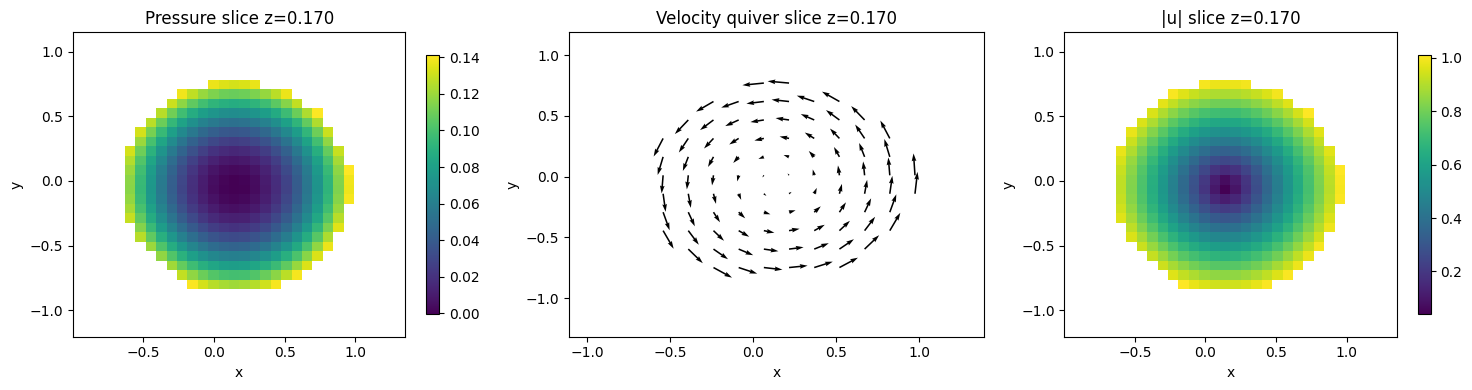

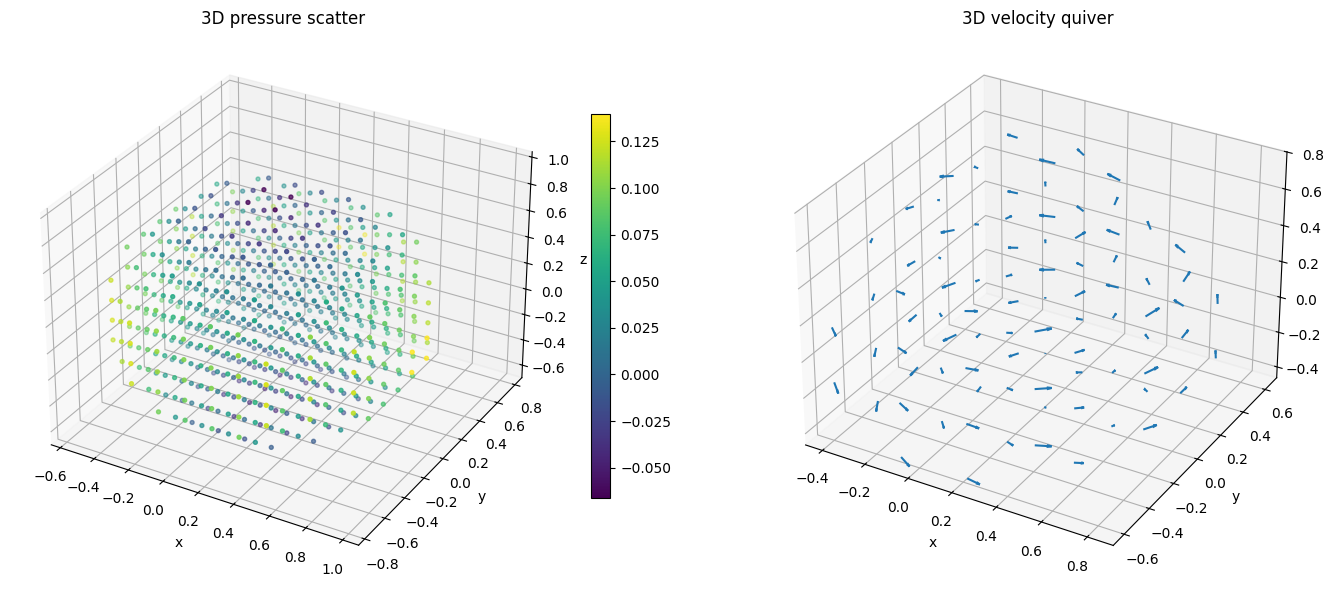

/Users/eliguli712/Library/Python/3.14/lib/python/site-packages/matplotlib/quiver.py:676: RuntimeWarning: Mean of empty slice
  amean = a[~self.Umask].mean()
/Users/eliguli712/Library/Python/3.14/lib/python/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


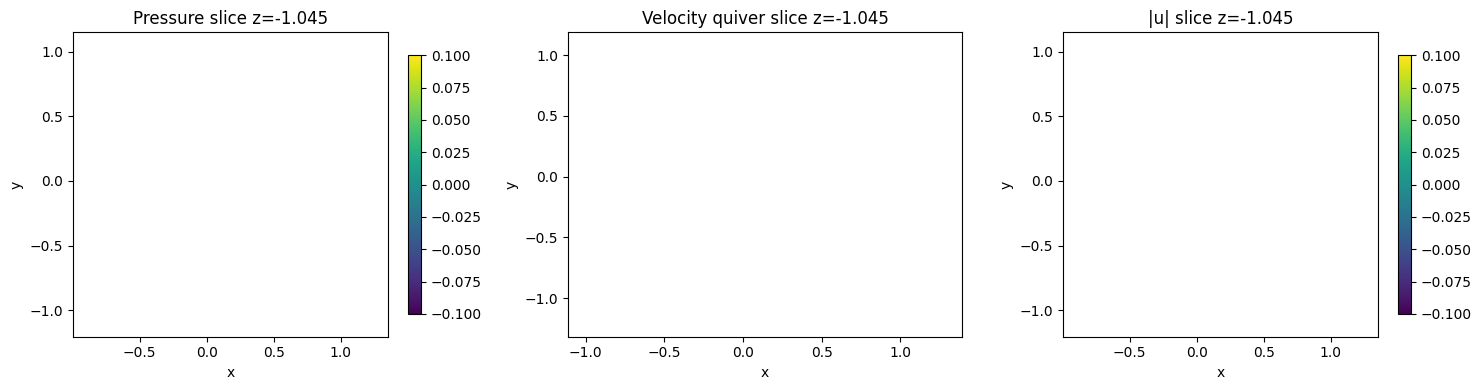

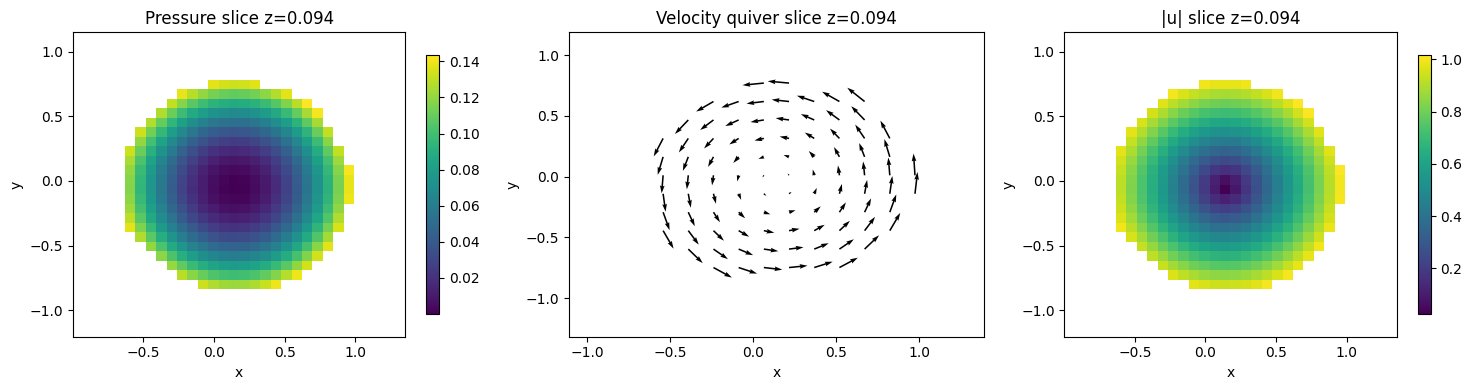

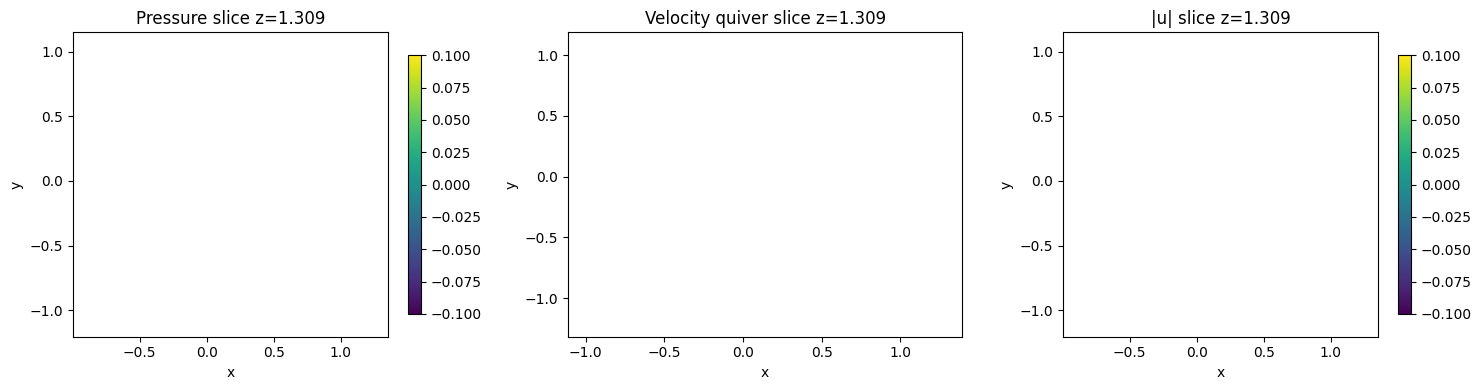

In [25]:
# 2D middle slice
visualize_u_p_2d(
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    xs=xs, ys=ys, zs=zs,
    inside_mask=inside_same,
    z_index=len(zs)//2,
    stride=2
)

# 3D view
visualize_u_p_3d(
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    xs=xs, ys=ys, zs=zs,
    inside_mask=inside_same,
    stride=4,
    pressure_stride=2
)

# multiple slices
visualize_u_p_multi_slice(
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    xs=xs, ys=ys, zs=zs,
    inside_mask=inside_same,
    num_slices=3,
    stride=2
)

In [26]:
import numpy as np

def steps_4_to_9(
    u_grid,           # (nx,ny,nz,3) at time n
    p_grid,           # (nx,ny,nz)   at time n
    rho_grid_np1,     # (nx,ny,nz)   at time n+1
    sigma_grid_np1,   # (nx,ny,nz,3,3) at time n+1
    dt,
    dx_tuple,         # (dx,dy,dz)
    body_force=None,  # (nx,ny,nz,3) optional
    poisson_iters=400,
    sigma_includes_minus_pI=True
):
    dx, dy, dz = map(float, dx_tuple)
    rho = np.asarray(rho_grid_np1, dtype=np.float64)
    inv_rho = 1.0 / np.maximum(rho, 1e-12)
    u = np.asarray(u_grid, dtype=np.float64)
    p = np.asarray(p_grid, dtype=np.float64)

    if body_force is None:
        body_force = np.zeros_like(u)

    def grad3_centered(F):
        Fx = np.empty_like(F); Fy = np.empty_like(F); Fz = np.empty_like(F)
        Fx[1:-1,:,:] = (F[2:,:,:] - F[:-2,:,:])/(2*dx)
        Fx[0,:,:]    = (F[1,:,:] - F[0,:,:])/dx
        Fx[-1,:,:]   = (F[-1,:,:] - F[-2,:,:])/dx

        Fy[:,1:-1,:] = (F[:,2:,:] - F[:,:-2,:])/(2*dy)
        Fy[:,0,:]    = (F[:,1,:] - F[:,0,:])/dy
        Fy[:,-1,:]   = (F[:,-1,:] - F[:,-2,:])/dy

        Fz[:,:,1:-1] = (F[:,:,2:] - F[:,:,:-2])/(2*dz)
        Fz[:,:,0]    = (F[:,:,1] - F[:,:,0])/dz
        Fz[:,:,-1]   = (F[:,:,-1] - F[:,:,-2])/dz
        return Fx, Fy, Fz

    def div3_centered(Fx, Fy, Fz):
        dFx_dx = np.empty_like(Fx)
        dFy_dy = np.empty_like(Fy)
        dFz_dz = np.empty_like(Fz)

        dFx_dx[1:-1,:,:] = (Fx[2:,:,:] - Fx[:-2,:,:])/(2*dx)
        dFx_dx[0,:,:]    = (Fx[1,:,:] - Fx[0,:,:])/dx
        dFx_dx[-1,:,:]   = (Fx[-1,:,:] - Fx[-2,:,:])/dx

        dFy_dy[:,1:-1,:] = (Fy[:,2:,:] - Fy[:,:-2,:])/(2*dy)
        dFy_dy[:,0,:]    = (Fy[:,1,:] - Fy[:,0,:])/dy
        dFy_dy[:,-1,:]   = (Fy[:,-1,:] - Fy[:,-2,:])/dy

        dFz_dz[:,:,1:-1] = (Fz[:,:,2:] - Fz[:,:,:-2])/(2*dz)
        dFz_dz[:,:,0]    = (Fz[:,:,1] - Fz[:,:,0])/dz
        dFz_dz[:,:,-1]   = (Fz[:,:,-1] - Fz[:,:,-2])/dz

        return dFx_dx + dFy_dy + dFz_dz

    def div_tensor_sigma(sigma):
        out = np.zeros(sigma.shape[:-1], dtype=np.float64)
        for i in range(3):
            s_ix = sigma[..., i, 0]
            s_iy = sigma[..., i, 1]
            s_iz = sigma[..., i, 2]
            dsx_dx, _, _ = grad3_centered(s_ix)
            _, dsy_dy, _ = grad3_centered(s_iy)
            _, _, dsz_dz = grad3_centered(s_iz)
            out[..., i] = dsx_dx + dsy_dy + dsz_dz
        return out

    def interp_to_xfaces(F): return 0.5 * (F[:-1,:,:] + F[1:,:,:])
    def interp_to_yfaces(F): return 0.5 * (F[:,:-1,:] + F[:,1:,:])
    def interp_to_zfaces(F): return 0.5 * (F[:,:,:-1] + F[:,:,1:])

    def div_from_face_flux(Fx_f, Fy_f, Fz_f):
        nx = Fy_f.shape[0]
        ny = Fx_f.shape[1]
        nz = Fx_f.shape[2]
        div = np.zeros((nx, ny, nz), dtype=np.float64)

        div[1:-1,:,:] += (Fx_f[1:,:,:] - Fx_f[:-1,:,:]) / dx
        div[0,:,:]    += Fx_f[0,:,:] / dx
        div[-1,:,:]   += -Fx_f[-1,:,:] / dx

        div[:,1:-1,:] += (Fy_f[:,1:,:] - Fy_f[:,:-1,:]) / dy
        div[:,0,:]    += Fy_f[:,0,:] / dy
        div[:,-1,:]   += -Fy_f[:,-1,:] / dy

        div[:,:,1:-1] += (Fz_f[:,:,1:] - Fz_f[:,:,:-1]) / dz
        div[:,:,0]    += Fz_f[:,:,0] / dz
        div[:,:,-1]   += -Fz_f[:,:,-1] / dz

        return div

    def solve_poisson_variable_coeff_jacobi(rhs, inv_rho, iters=400, omega=0.8):
        nx, ny, nz = rhs.shape
        dp = np.zeros_like(rhs, dtype=np.float64)

        dx2, dy2, dz2 = dx*dx, dy*dy, dz*dz

        ax = 0.5 * (inv_rho[:-1, :, :] + inv_rho[1:, :, :])   # (nx-1, ny, nz)
        ay = 0.5 * (inv_rho[:, :-1, :] + inv_rho[:, 1:, :])   # (nx, ny-1, nz)
        az = 0.5 * (inv_rho[:, :, :-1] + inv_rho[:, :, 1:])   # (nx, ny, nz-1)

        for _ in range(iters):
            dp_new = dp.copy()

            for i in range(1, nx - 1):
                for j in range(1, ny - 1):
                    for k in range(1, nz - 1):
                        axm = ax[i - 1, j, k]
                        axp = ax[i,     j, k]
                        aym = ay[i, j - 1, k]
                        ayp = ay[i, j,     k]
                        azm = az[i, j, k - 1]
                        azp = az[i, j, k]

                        denom = (
                            (axm + axp) / dx2 +
                            (aym + ayp) / dy2 +
                            (azm + azp) / dz2
                        )

                        numer = (
                            (axm * dp[i - 1, j, k] + axp * dp[i + 1, j, k]) / dx2 +
                            (aym * dp[i, j - 1, k] + ayp * dp[i, j + 1, k]) / dy2 +
                            (azm * dp[i, j, k - 1] + azp * dp[i, j, k + 1]) / dz2
                        )

                        dp_new[i, j, k] = (numer - rhs[i, j, k]) / max(denom, 1e-30)

            # Neumann-style boundary copy
            dp_new[0, :, :]  = dp_new[1, :, :]
            dp_new[-1, :, :] = dp_new[-2, :, :]
            dp_new[:, 0, :]  = dp_new[:, 1, :]
            dp_new[:, -1, :] = dp_new[:, -2, :]
            dp_new[:, :, 0]  = dp_new[:, :, 1]
            dp_new[:, :, -1] = dp_new[:, :, -2]

            dp = (1.0 - omega) * dp + omega * dp_new

        dp -= np.mean(dp)
        return dp

    # =====================================================
    # Step 4a: u*
    # =====================================================
    adv = np.zeros_like(u)
    for i in range(3):
        ui = u[..., i]
        Fx = rho * ui * u[..., 0]
        Fy = rho * ui * u[..., 1]
        Fz = rho * ui * u[..., 2]
        adv[..., i] = div3_centered(Fx, Fy, Fz)

    # FIXED BROADCAST HERE
    u_star = (rho[..., None] * u - dt * adv) * inv_rho[..., None]

    # =====================================================
    # Step 4b: u**
    # =====================================================
    I = np.eye(3, dtype=np.float64)[None, None, None, :, :]
    if sigma_includes_minus_pI:
        sigma_eff = sigma_grid_np1 + p[..., None, None] * I
    else:
        sigma_eff = sigma_grid_np1

    divsig = div_tensor_sigma(sigma_eff)
    u_dblstar = u_star + dt * inv_rho[..., None] * (divsig + body_force)

    # =====================================================
    # Step 5: face velocity u_f**
    # =====================================================
    rho_xf = interp_to_xfaces(rho); inv_rho_xf = 1.0 / np.maximum(rho_xf, 1e-12)
    rho_yf = interp_to_yfaces(rho); inv_rho_yf = 1.0 / np.maximum(rho_yf, 1e-12)
    rho_zf = interp_to_zfaces(rho); inv_rho_zf = 1.0 / np.maximum(rho_zf, 1e-12)

    ux, uy, uz = u_dblstar[...,0], u_dblstar[...,1], u_dblstar[...,2]
    uxf = np.stack([interp_to_xfaces(ux), interp_to_xfaces(uy), interp_to_xfaces(uz)], axis=-1)
    uyf = np.stack([interp_to_yfaces(ux), interp_to_yfaces(uy), interp_to_yfaces(uz)], axis=-1)
    uzf = np.stack([interp_to_zfaces(ux), interp_to_zfaces(uy), interp_to_zfaces(uz)], axis=-1)

    dpdx_xf = (p[1:,:,:] - p[:-1,:,:]) / dx
    dpdy_yf = (p[:,1:,:] - p[:,:-1,:]) / dy
    dpdz_zf = (p[:,:,1:] - p[:,:,:-1]) / dz

    uxf[..., 0] -= dt * inv_rho_xf * dpdx_xf
    uyf[..., 1] -= dt * inv_rho_yf * dpdy_yf
    uzf[..., 2] -= dt * inv_rho_zf * dpdz_zf

    # =====================================================
    # Step 6: solve for δp
    # =====================================================
    Fx = uxf[..., 0]
    Fy = uyf[..., 1]
    Fz = uzf[..., 2]
    rhs = -div_from_face_flux(Fx / dt, Fy / dt, Fz / dt)
    dp = solve_poisson_variable_coeff_jacobi(rhs, inv_rho, iters=poisson_iters, omega=0.8)

    # =====================================================
    # Step 7: p^{n+1}
    # =====================================================
    p_np1 = p + dp

    # =====================================================
    # Step 8: face velocity u_f^{n+1}
    # =====================================================
    dpdx_xf = (dp[1:,:,:] - dp[:-1,:,:]) / dx
    dpdy_yf = (dp[:,1:,:] - dp[:,:-1,:]) / dy
    dpdz_zf = (dp[:,:,1:] - dp[:,:,:-1]) / dz

    uxf_np1 = uxf.copy()
    uyf_np1 = uyf.copy()
    uzf_np1 = uzf.copy()

    uxf_np1[..., 0] -= dt * inv_rho_xf * dpdx_xf
    uyf_np1[..., 1] -= dt * inv_rho_yf * dpdy_yf
    uzf_np1[..., 2] -= dt * inv_rho_zf * dpdz_zf

    # =====================================================
    # Step 9: cell-centered velocity u^{n+1}
    # =====================================================
    corr_xf = dt * inv_rho_xf * dpdx_xf
    corr_yf = dt * inv_rho_yf * dpdy_yf
    corr_zf = dt * inv_rho_zf * dpdz_zf

    corr_x = np.zeros_like(p)
    corr_y = np.zeros_like(p)
    corr_z = np.zeros_like(p)

    corr_x[1:-1,:,:] = 0.5 * (corr_xf[:-1,:,:] + corr_xf[1:,:,:])
    corr_x[0,:,:]    = corr_xf[0,:,:]
    corr_x[-1,:,:]   = corr_xf[-1,:,:]

    corr_y[:,1:-1,:] = 0.5 * (corr_yf[:,:-1,:] + corr_yf[:,1:,:])
    corr_y[:,0,:]    = corr_yf[:,0,:]
    corr_y[:,-1,:]   = corr_yf[:,-1,:]

    corr_z[:,:,1:-1] = 0.5 * (corr_zf[:,:,:-1] + corr_zf[:,:,1:])
    corr_z[:,:,0]    = corr_zf[:,:,0]
    corr_z[:,:,-1]   = corr_zf[:,:,-1]

    u_np1 = u_dblstar.copy()
    u_np1[..., 0] -= corr_x
    u_np1[..., 1] -= corr_y
    u_np1[..., 2] -= corr_z

    u_f_np1 = {"x": uxf_np1, "y": uyf_np1, "z": uzf_np1}

    return u_star, u_dblstar, dp, p_np1, u_f_np1, u_np1

In [27]:
u_star, u_dblstar, dp, p_np1, u_f_np1, u_np1 = steps_4_to_9(
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    rho_grid_np1=rho_grid_np1,
    sigma_grid_np1=sigma_grid_np1,
    dt=dt,
    dx_tuple=dx_tuple,
    body_force=None,
    poisson_iters=400,
    sigma_includes_minus_pI=True
)

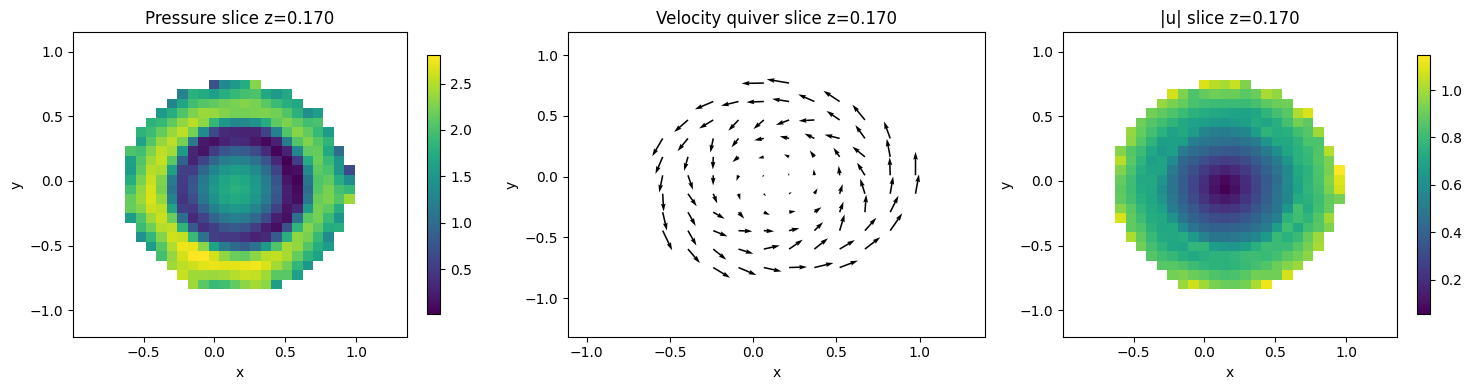

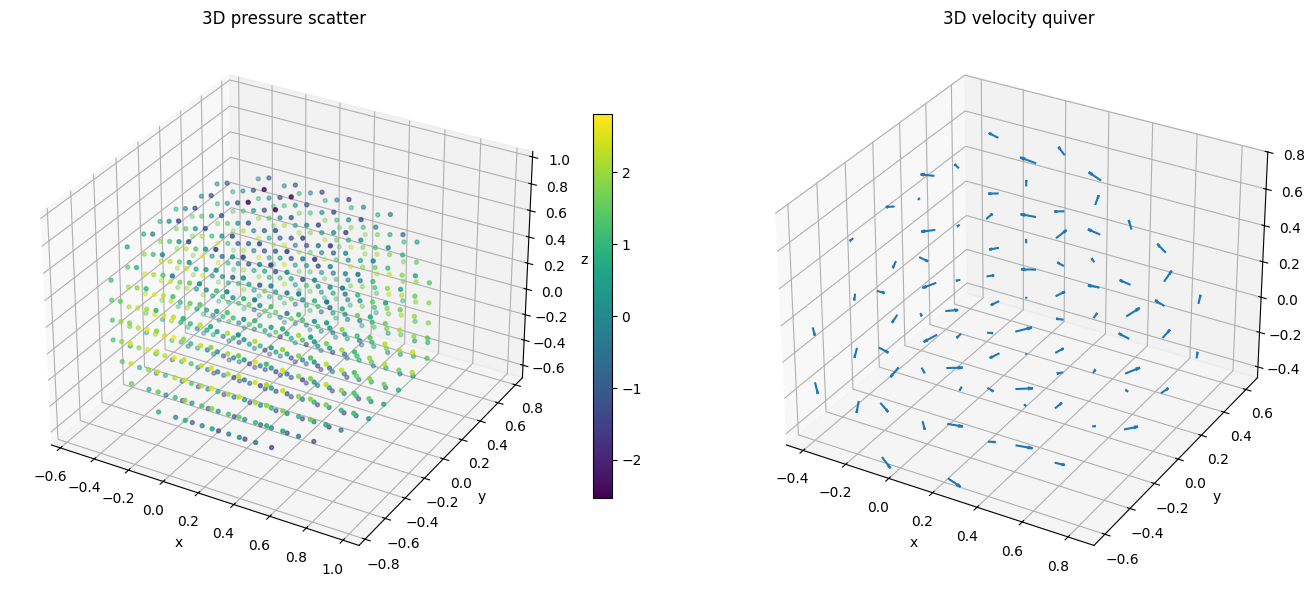

In [28]:
visualize_u_p_2d(u_np1, p_np1, xs, ys, zs, inside_same)
visualize_u_p_3d(u_np1, p_np1, xs, ys, zs, inside_same)

In [29]:
import numpy as np

# ---------------------------------------
# Rebuild xs, ys, zs without needing `out`
# ---------------------------------------
nx, ny, nz = p_grid_n.shape
dx, dy, dz = map(float, dx_tuple)

xmin = pts.min(axis=0)
xmax = pts.max(axis=0)
extent = xmax - xmin
grid_pad = 0.18
pad = grid_pad * np.maximum(extent, 1e-12)
gmin = xmin - pad

xs = gmin[0] + dx * np.arange(nx)
ys = gmin[1] + dy * np.arange(ny)
zs = gmin[2] + dz * np.arange(nz)

# ---------------------------------------
# Rebuild inside-hull mask on this grid
# ---------------------------------------
Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
grid_points_same = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()])

A = hull.equations[:, :3]
d = hull.equations[:, 3]
inside_same = np.all((A @ grid_points_same.T) + d[:, None] <= 1e-12, axis=0).reshape(Xg.shape)

print("Recovered axes lengths:", len(xs), len(ys), len(zs))
print("Grid shape from axes   :", Xg.shape)
print("u_grid_n shape         :", u_grid_n.shape)
print("p_grid_n shape         :", p_grid_n.shape)

# ---------------------------------------
# PyVista plot
# ---------------------------------------
plot_pressure_slices_streamlines(
    xs=xs,
    ys=ys,
    zs=zs,
    u_grid=u_grid_n,
    p_grid=p_grid_n,
    inside_mask=inside_same,
    pts=pts,
    hull=hull,
    show_volume=True,
    show_slices=True,
    show_streamlines=True,
    show_glyphs=False,
    show_hull=True,
    streamline_stride=3,
)

Recovered axes lengths: 32 32 32
Grid shape from axes   : (32, 32, 32)
u_grid_n shape         : (32, 32, 32, 3)
p_grid_n shape         : (32, 32, 32)


In [30]:
plot_pressure_slices_streamlines(
    xs=xs,
    ys=ys,
    zs=zs,
    u_grid=u_np1,
    p_grid=p_np1,
    inside_mask=inside_same,
    pts=pts,
    hull=hull,
    show_volume=True,
    show_slices=True,
    show_streamlines=True,
    show_glyphs=False,
    show_hull=True,
    streamline_stride=3,
)